In [ ]:
from sage.groups.braid import BraidGroup

class TorusKnot:
    """
    A class representing a torus knot with associated binary lists.
    
    Each TorusKnot object contains:
    - list1: A binary list (elements are 0 or 1)
    - list2: A binary list (elements are 0 or 1)
    - braid: A Braid object from SageMath's BraidGroup
    
    Parameters
    ----------
    list1 : list
        First binary list (values must be 0 or 1)
    list2 : list
        Second binary list (values must be 0 or 1)
    braid_word : list, optional
        A list of indices representing the braid word. If None, creates the identity braid.
    """
    
    def __init__(self, list1, list2, braid_word=None):
        """Initialize a TorusKnot object.

        The two binary lists may have different lengths, but they must contain
        the same number of 1s.
        """

        # Validate that lists are binary (contain only 0s and 1s)
        for lst in [list1, list2]:
            if not all(x in [0, 1] for x in lst):
                raise ValueError("Lists must be binary (contain only 0s and 1s)")

        if sum(list1) != sum(list2):
            raise ValueError("Lists must contain the same number of 1s")

        # Number of strands is the sum of the lengths minus the number of ones in list2
        self.list1 = list(list1)
        self.list2 = list(list2)
        self.n = len(self.list1) + len(self.list2) - sum(self.list2)
        if self.n <= 0:
            raise ValueError("Number of strands must be positive after applying rule")

        # Create the braid with number of strands equal to the sum
        self.braid_group = BraidGroup(self.n)

        if braid_word is None:
            self.braid = self.braid_group.one()
        else:
            self.braid = self.braid_group(braid_word)

    def __repr__(self):
        """String representation of the TorusKnot."""
        return (f"TorusKnot(list1={self.list1}, list2={self.list2}, "
                f"braid={self.braid})")

    def __str__(self):
        """Human-readable string representation."""
        return (f"Torus Knot:\n"
                f"  Binary list 1: {self.list1}\n"
                f"  Binary list 2: {self.list2}\n"
                f"  Braid: {self.braid}")

    def visualize(self, figsize=(6,4), show=True, savepath=None):
        """Draw a wider rectangle and connect left-side points to the other sides.

        - Elements of `list1` are placed along the left edge (first element at the bottom).
        - Elements of `list2` are placed along the bottom edge (first element at the left).
        - Each left-side point connects to the matching bottom-side point when one exists.
        - Zeros in `list2` also get unlabeled points directly above them on the top edge.
        - If `list2` is longer, top-edge zero points are treated as extensions of `list1`:
          the leftmost top point connects to `list2[len(list1)]`, then the next, and so on.
          Any leftover points after that route to RHS anchors.

        The bottom and top sides run from x=0 to x=`width`, where `width` is
        fixed to be 1.75 times the height (which is 1). Points are shifted inward
        so no point sits exactly on a corner. Returns `(fig, ax)`.
        """
        import matplotlib.pyplot as plt

        fig, ax = plt.subplots(figsize=figsize)

        # fixed width = 1.75 * height(=1)
        width = 1.75
        inset = 0.12

        # draw rectangle: (0,0) bottom-left to (width,1) top-right
        ax.plot([0, width, width, 0, 0], [0, 0, 1, 1, 0], color='black')

        # left side points: x=0, y inset away from corners
        n1 = len(self.list1)
        if n1 == 0:
            left_xs, left_ys = [], []
        elif n1 == 1:
            left_xs, left_ys = [0.0], [0.5]
        else:
            left_xs = [0.0] * n1
            left_ys = [inset + i * ((1 - 2 * inset) / (n1 - 1)) for i in range(n1)]

        # bottom side points: y=0, x inset away from corners
        n2 = len(self.list2)
        if n2 == 0:
            bottom_xs, bottom_ys = [], []
        elif n2 == 1:
            bottom_xs, bottom_ys = [width / 2], [0.0]
        else:
            bottom_xs = [inset + i * ((width - 2 * inset) / (n2 - 1)) for i in range(n2)]
            bottom_ys = [0.0] * n2

        # zero-valued bottom indices (verticals)
        zero_indices = [i for i, value in enumerate(self.list2) if value == 0]
        top_xs_all = [bottom_xs[i] for i in zero_indices]
        top_ys_all = [1.0] * len(top_xs_all)
        top_zero_indices = sorted(zero_indices, key=lambda i: bottom_xs[i])

        # extra points on each side
        extra_left = max(0, n1 - n2)
        extra_bottom = max(0, n2 - n1)

        # when the bottom side is longer, use top-edge zero points as extensions of list1
        top_extension_count = min(len(top_zero_indices), extra_bottom)
        top_to_bottom_indices = top_zero_indices[:top_extension_count]
        remaining_top_zero_indices = top_zero_indices[top_extension_count:]
        remaining_bottom_indices = list(range(n1 + top_extension_count, n2)) if extra_bottom > top_extension_count else []

        # right-edge anchors are only needed for leftover points after the primary pairings
        rhs_count = extra_left + len(remaining_top_zero_indices) + len(remaining_bottom_indices)
        if rhs_count > 0:
            right_xs = [width] * rhs_count
            right_ys = [inset + i * ((1 - 2 * inset) / (rhs_count - 1)) for i in range(rhs_count)] if rhs_count > 1 else [0.5]
        else:
            right_xs, right_ys = [], []

        # Build segments to consider for intersections.
        segments = []
        pair_count = min(n1, n2)
        # paired left->bottom
        for i in range(pair_count):
            segments.append((left_xs[i], left_ys[i], bottom_xs[i], bottom_ys[i]))

        rhs_cursor = 0
        # surplus left -> right (when left is longer than bottom)
        for j in range(extra_left):
            i = n2 + j
            segments.append((left_xs[i], left_ys[i], right_xs[rhs_cursor], right_ys[rhs_cursor]))
            rhs_cursor += 1

        # when bottom is longer, pair the leftmost top points to the extra bottom points
        for idx, bi in enumerate(top_to_bottom_indices):
            x_top = bottom_xs[bi]
            x_bottom = bottom_xs[n1 + idx]
            segments.append((x_top, 1.0, x_bottom, 0.0))

        # any remaining top points route to the RHS
        for bi in remaining_top_zero_indices:
            x_top = bottom_xs[bi]
            segments.append((x_top, 1.0, right_xs[rhs_cursor], right_ys[rhs_cursor]))
            rhs_cursor += 1

        # any remaining bottom points also route to the RHS
        for bottom_idx in remaining_bottom_indices:
            segments.append((bottom_xs[bottom_idx], 0.0, right_xs[rhs_cursor], right_ys[rhs_cursor]))
            rhs_cursor += 1

        def vertical_segments_with_gaps(x0, y0=0.0, y1=1.0, gap=0.03):
            """Return list of (x0,x0,y_start,y_end) vertical segments excluding small gaps around intersections."""
            ys = []
            for (x1, y1_s, x2, y2_s) in segments:
                if x1 == x2:
                    continue
                if not (min(x1, x2) <= x0 <= max(x1, x2)):
                    continue
                t = (x0 - x1) / (x2 - x1)
                y_at = y1_s + t * (y2_s - y1_s)
                if min(y1_s, y2_s) <= y_at <= max(y1_s, y2_s):
                    ys.append(y_at)
            ys = sorted(set(ys))

            # start with full interval then cut out [y-gap, y+gap] around each intersection
            intervals = [(y0, y1)]
            for y in ys:
                new_intervals = []
                low = y - gap
                high = y + gap
                for (a, b) in intervals:
                    if high <= a or low >= b:
                        new_intervals.append((a, b))
                    else:
                        if a < low:
                            new_intervals.append((a, low))
                        if high < b:
                            new_intervals.append((high, b))
                intervals = new_intervals
            # filter very small pieces
            return [(x0, x0, a, b) for (a, b) in intervals if (b - a) > 1e-4]

        # draw bottom-to-top connections for zeros first with gaps so they appear to go under others
        for i in zero_indices:
            x0 = bottom_xs[i]
            segs = vertical_segments_with_gaps(x0, y0=0.0, y1=1.0, gap=0.03)
            for (_x1, _x2, ya, yb) in segs:
                ax.plot([x0, x0], [ya, yb], color='0.35', linewidth=1.2, zorder=0)

        # draw left-side connecting strands (paired)
        for i in range(pair_count):
            ax.plot([left_xs[i], bottom_xs[i]], [left_ys[i], bottom_ys[i]], color='gray', linewidth=1.5, zorder=1)

        # draw surplus left->right routing when left is longer than bottom
        for j in range(extra_left):
            i = n2 + j
            ax.plot([left_xs[i], right_xs[j]], [left_ys[i], right_ys[j]], color='gray', linewidth=1.5, zorder=1)

        # draw top->bottom extensions when the bottom list is longer
        for idx, bi in enumerate(top_to_bottom_indices):
            x_top = bottom_xs[bi]
            x_bottom = bottom_xs[n1 + idx]
            ax.plot([x_top, x_bottom], [1.0, 0.0], color='gray', linewidth=1.5, zorder=1)

        # draw any remaining top points to the RHS
        rhs_cursor = extra_left
        for bi in remaining_top_zero_indices:
            x_top = bottom_xs[bi]
            ax.plot([x_top, right_xs[rhs_cursor]], [1.0, right_ys[rhs_cursor]], color='gray', linewidth=1.5, zorder=1)
            rhs_cursor += 1

        # draw any remaining bottom points to the RHS
        for bottom_idx in remaining_bottom_indices:
            ax.plot([bottom_xs[bottom_idx], right_xs[rhs_cursor]], [0.0, right_ys[rhs_cursor]], color='gray', linewidth=1.5, zorder=1)
            rhs_cursor += 1

        # plot points
        ax.scatter(left_xs, left_ys, color='blue', zorder=5)
        ax.scatter(bottom_xs, bottom_ys, color='red', zorder=5)
        # RHS anchors remain unlabeled
        if right_xs:
            ax.scatter(right_xs, right_ys, color='green', zorder=5)
        if top_xs_all:
            ax.scatter(top_xs_all, top_ys_all, color='purple', zorder=5)

        # annotate with the element value for left and bottom only
        for i, (x, y) in enumerate(zip(left_xs, left_ys)):
            ax.text(x - 0.03 * width, y, str(self.list1[i]), verticalalignment='center', horizontalalignment='right')
        for i, (x, y) in enumerate(zip(bottom_xs, bottom_ys)):
            ax.text(x, y - 0.03, str(self.list2[i]), verticalalignment='top', horizontalalignment='center')

        ax.set_xlim(-0.1 * width, 1.15 * width)
        ax.set_ylim(-0.1, 1.1)
        ax.set_aspect('equal')
        ax.axis('off')

        if savepath:
            fig.savefig(savepath, bbox_inches='tight')
        if show:
            plt.show()
        return fig, ax

Torus Knot:
  Binary list 1: [0, 1, 0]
  Binary list 2: [0, 0, 1]
  Braid: s0*s1*s0
TorusKnot(list1=[0, 1, 0], list2=[0, 0, 1], braid=s0*s1*s0)


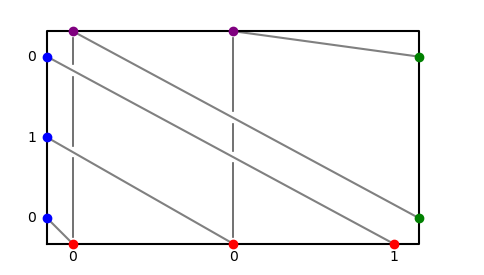

(<Figure size 600x400 with 1 Axes>, <Axes: >)

In [47]:
# Example usage of TorusKnot class

# Create a simple torus knot
list1 = [0, 1, 0]
list2 = [0, 0, 1]
braid_word = [1, 2, 1]  # A simple braid word

tk = TorusKnot(list1, list2, braid_word)
print(tk)
print(repr(tk))
tk.visualize()